# Pareto Frontier vs. Cluster Size

**Question:** as the cluster grows from 64 to 1024 GPUs (per-device hardware held fixed), how does the (throughput/GPU, interactivity) Pareto frontier shift? Which partitions win at each size, and why?

**Setup:** GPT-1.8T MoE @ FP4 on GB200-class devices (192 GB HBM @ 8 TB/s, 9000 TF, 900 GB/s · 0.5 μs scale-up, held uniform as we scale `num_devices` — a hypothetical sweep that ignores real-world scale-out fabric changes beyond the 72-GPU NVL72 rack). For each `N ∈ {64, 128, 256, 512, 1024}`:

1. Enumerate every valid `(PP, TP, EP, SP)` partition with `PP·TP·EP·SP ≤ N`.
2. For each partition, sweep `B` up to the KV-paging max.
3. Extract the upper-right envelope in (throughput/GPU, interactivity) space.

**Divisibility constraints for this model:**

- `PP | L=120` → PP ∈ {1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 24, 30, 40, 60, 120}
- `TP | n_kv=16` → TP ∈ {1, 2, 4, 8, 16}  (capped by GQA replication)
- `EP | n_experts=16` → EP ∈ {1, 2, 4, 8, 16}  (capped by expert count)

TP and EP can't go past 16 without changing the model; PP can go all the way to 120.

**Why per-GPU metrics aren't trivially invariant.** Naively, adding more devices = more DP replicas, and per-GPU throughput should be flat. But `DP = N // (PP·TP·EP·SP)` is floored — if `N` isn't a clean multiple of the replica size, leftover devices sit idle and drag down `TTPS / N`. The competition between partition shapes is partly a **device-utilization** competition.

## 1. Imports and spec loading

In [1]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5

CLUSTER_SIZES = [64, 128, 256, 512, 1024]

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
base_system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

print(f"Model:   {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"Device:  HBM={base_system.device.hbm_bandwidth_GBps:.0f} GB/s  "
      f"peak={base_system.device.peak_flops_TF:.0f} TF  "
      f"scale-up={base_system.network_domains['TP'].bandwidth_GBps:.0f} GB/s · "
      f"{base_system.network_domains['TP'].alpha_us:.2f} μs")
print(f"Cluster sizes: {CLUSTER_SIZES}")

Model:   GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
Device:  HBM=8000 GB/s  peak=9000 TF  scale-up=900 GB/s · 0.50 μs
Cluster sizes: [64, 128, 256, 512, 1024]


## 2. Partition enumeration and sweep helpers

Full divisor set for `PP | 120` — that's the lever with room to grow as `N` scales. TP and EP are capped by the model (`n_kv = n_experts = 16`).

In [2]:
PP_CHOICES = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 24, 30, 40, 60, 120]
TP_CHOICES = [1, 2, 4, 8, 16]
EP_CHOICES = [1, 2, 4, 8, 16]
SP_CHOICES = [1]


@dataclass
class Point:
    N: int
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"

    @property
    def replica(self) -> int:
        p = self.partition
        return p.PP * p.TP * p.EP * p.SP


def enumerate_partitions(n: int) -> list[PartitionSpec]:
    out: list[PartitionSpec] = []
    for pp in PP_CHOICES:
        for tp in TP_CHOICES:
            for ep in EP_CHOICES:
                for sp in SP_CHOICES:
                    if pp * tp * ep * sp > n:
                        continue
                    out.append(PartitionSpec(PP=pp, TP=tp, EP=ep, SP=sp))
    return out


def log_spaced_B(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def make_system_with_N(N: int):
    s = deepcopy(base_system)
    s.num_devices = N
    return s


def sweep_partition(system, partition: PartitionSpec) -> list[Point]:
    try:
        mem = compute_memory(model, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    pts: list[Point] = []
    for B in log_spaced_B(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            N=system.num_devices,
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best = -math.inf
    for p in sorted_pts:
        if p.interactivity > best + 1e-9:
            frontier.append(p)
            best = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier

## 3. Run the sweep

In [3]:
cloud_by_N: dict[int, list[Point]] = {}
frontier_by_N: dict[int, list[Point]] = {}

for N in CLUSTER_SIZES:
    sys_N = make_system_with_N(N)
    parts = enumerate_partitions(N)
    all_pts: list[Point] = []
    for part in parts:
        all_pts.extend(sweep_partition(sys_N, part))
    fr = pareto_frontier(all_pts)
    cloud_by_N[N] = all_pts
    frontier_by_N[N] = fr
    feasible_parts = len({p.part_label for p in all_pts})
    print(f"N={N:4d}  partitions(valid)={len(parts):3d}  "
          f"partitions(feasible)={feasible_parts:3d}  "
          f"evaluations={len(all_pts):5d}  frontier={len(fr):3d}")

N=  64  partitions(valid)=130  partitions(feasible)=119  evaluations= 3542  frontier= 32
N= 128  partitions(valid)=184  partitions(feasible)=173  evaluations= 5586  frontier= 34
N= 256  partitions(valid)=240  partitions(feasible)=229  evaluations= 7876  frontier= 34


N= 512  partitions(valid)=292  partitions(feasible)=281  evaluations=10156  frontier= 37


N=1024  partitions(valid)=335  partitions(feasible)=324  evaluations=12164  frontier= 39


## 4. Winners per N — with DP and device utilization

For each frontier winner we also report `DP = N // replica` (floored) and `util = DP · replica / N`. A partition with util < 100% is wasting devices; it can still win a corner if its arithmetic profile beats fully-utilized alternatives at that corner.

In [4]:
for N in CLUSTER_SIZES:
    counts: dict[str, int] = {}
    for p in frontier_by_N[N]:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    ranked = sorted(counts.items(), key=lambda kv: -kv[1])
    print(f"N={N}:")
    for label, cnt in ranked:
        parts = {kv.split('=')[0]: int(kv.split('=')[1]) for kv in label.split()}
        replica = parts['PP'] * parts['TP'] * parts['EP'] * parts['SP']
        dp = N // replica
        util = dp * replica / N
        print(f"  {label:32s}  ×{cnt:<3d}  replica={replica:4d}  DP={dp:3d}  util={util*100:5.1f}%")

N=64:
  PP=60 TP=1 EP=1 SP=1              ×25   replica=  60  DP=  1  util= 93.8%
  PP=30 TP=2 EP=1 SP=1              ×5    replica=  60  DP=  1  util= 93.8%
  PP=15 TP=4 EP=1 SP=1              ×2    replica=  60  DP=  1  util= 93.8%
N=128:
  PP=120 TP=1 EP=1 SP=1             ×26   replica= 120  DP=  1  util= 93.8%
  PP=30 TP=4 EP=1 SP=1              ×4    replica= 120  DP=  1  util= 93.8%
  PP=60 TP=2 EP=1 SP=1              ×4    replica= 120  DP=  1  util= 93.8%
N=256:
  PP=120 TP=2 EP=1 SP=1             ×30   replica= 240  DP=  1  util= 93.8%
  PP=60 TP=4 EP=1 SP=1              ×4    replica= 240  DP=  1  util= 93.8%
N=512:
  PP=120 TP=4 EP=1 SP=1             ×26   replica= 480  DP=  1  util= 93.8%
  PP=120 TP=2 EP=1 SP=1             ×8    replica= 240  DP=  2  util= 93.8%
  PP=60 TP=8 EP=1 SP=1              ×3    replica= 480  DP=  1  util= 93.8%
N=1024:
  PP=120 TP=8 EP=1 SP=1             ×22   replica= 960  DP=  1  util= 93.8%
  PP=120 TP=4 EP=1 SP=1             ×8    replica= 48

## 6. Takeaways

- **Winning PP climbs as `N` grows, until `PP = L = 120`.** At `N=64` the best PP is 60 (one layer per 2 devices via DP or TP); at `N≥128`, `PP=120` (one layer per rank) dominates. Beyond that, extra devices go to TP (or DP replicas).
- **Winning TP steps 1 → 1 → 2 → 4 → 8 as `N` doubles from 64 → 1024.** Once `PP=120` saturates layer depth, TP is the next-best lever for weight-read amortization. EP stays at 1 throughout — at this scale and batch, MoE routing overhead outweighs expert parallelism.
- **Device utilization is the silent cost.** `DP = N // replica` is floored, so partitions whose `replica` doesn't divide `N` leave devices idle. In this sweep every N admits a nice ≥ 93.8% util shape — but "in-between" cluster sizes (e.g. N=768) force a choice between two partial-utilization partitions, producing a diverse but less efficient frontier.
- **Per-GPU throughput saturates past `PP=L`.** Once one layer per rank is reached, doubling `N` only helps via TP collective amortization or additional DP replicas. The frontier shifts up modestly at `N ∈ {512, 1024}` and would plateau beyond `N=1920 = 120·16` (the largest single replica the model admits with full PP+TP+EP).
- **Caveat on scale-up fabric.** This sweep holds per-device scale-up BW and α uniform across all N — a hypothetical. Real multi-rack clusters past NVL72 (72 GPUs) pay a tier change for inter-rack traffic. Re-run with realistic scale-out specs for a production-relevant answer.
- **Practical rule:** for this model, pick cluster sizes that are **multiples of L=120** (or of `60`) to land on high-utilization frontiers. Sizes like 768, which don't divide the PP=120 replica cleanly, get stuck at 62–83% util.


## 7. Fabric efficiency sensitivity (η < 1)

The sweep above holds scale-up BW constant at 900 GB/s regardless of cluster size — equivalent to adding more NVSwitch chips to maintain full bisection bandwidth. In practice, larger fabrics suffer head-of-line blocking, buffering contention, and protocol overhead that reduce effective BW.

We model this as a **diminishing η schedule** applied to all network domains:

| N | η | Rationale |
|---|---|-----------|
| 64 | 1.00 | Within single NVL72 domain |
| 128 | 1.00 | Two racks, well-provisioned |
| 256 | 0.90 | Multi-rack, mild congestion |
| 512 | 0.80 | Cross-rack hops, HoL blocking |
| 1024 | 0.70 | Large fabric, cumulative losses |

Re-run only N ∈ {256, 512, 1024} and overlay dashed η-discounted frontiers on the original η=1.0 curves.

In [5]:
ETA_SCHEDULE = {256: 0.90, 512: 0.80, 1024: 0.70}

def make_system_with_N_eta(N: int, eta: float):
    """Deepcopy base system, set num_devices, scale all network domain BWs by η."""
    s = deepcopy(base_system)
    s.num_devices = N
    for dom in s.network_domains.values():
        dom.bandwidth_GBps *= eta
    return s

frontier_eta_by_N: dict[int, list[Point]] = {}
cloud_eta_by_N: dict[int, list[Point]] = {}

for N, eta in ETA_SCHEDULE.items():
    sys_N = make_system_with_N_eta(N, eta)
    parts = enumerate_partitions(N)
    all_pts: list[Point] = []
    for part in parts:
        all_pts.extend(sweep_partition(sys_N, part))
    fr = pareto_frontier(all_pts)
    cloud_eta_by_N[N] = all_pts
    frontier_eta_by_N[N] = fr
    feasible_parts = len({p.part_label for p in all_pts})
    print(f"N={N:4d}  η={eta:.2f}  "
          f"feasible={feasible_parts:3d}  "
          f"evaluations={len(all_pts):5d}  frontier={len(fr):3d}")

N= 256  η=0.90  feasible=229  evaluations= 7876  frontier= 34


N= 512  η=0.80  feasible=281  evaluations=10156  frontier= 39


N=1024  η=0.70  feasible=324  evaluations=12164  frontier= 40


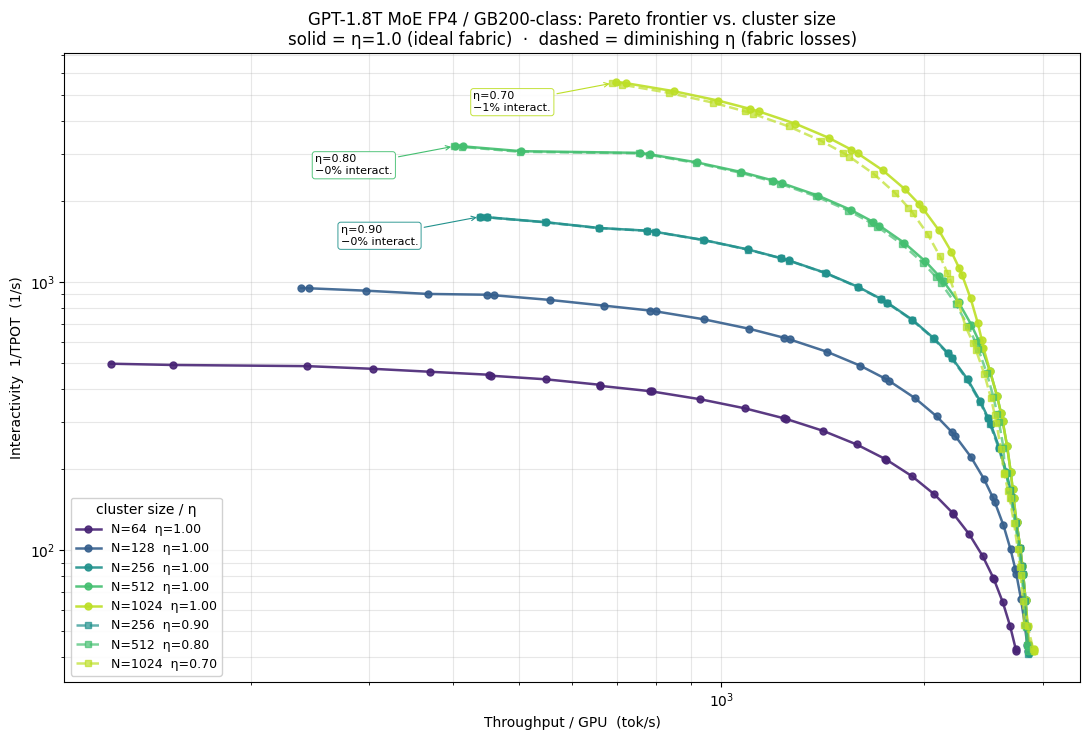

Saved → assets/pareto_vs_cluster_size.png


In [6]:
cmap = plt.get_cmap("viridis")
colors = {N: cmap(0.1 + 0.8 * i / max(1, len(CLUSTER_SIZES) - 1))
          for i, N in enumerate(CLUSTER_SIZES)}

fig, ax = plt.subplots(figsize=(11, 7.5))

# Plot η=1.0 frontiers for ALL cluster sizes (solid lines)
for N in CLUSTER_SIZES:
    fr = frontier_by_N[N]
    if not fr:
        continue
    xs = [p.tput_per_gpu for p in fr]
    ys = [p.interactivity for p in fr]
    ax.plot(xs, ys, "-o", lw=1.8, ms=5, color=colors[N], alpha=0.9,
            label=f"N={N}  η=1.00")

# Overlay η-discounted frontiers as dashed lines (N=256, 512, 1024 only)
for N, eta in ETA_SCHEDULE.items():
    fr = frontier_eta_by_N[N]
    if not fr:
        continue
    xs = [p.tput_per_gpu for p in fr]
    ys = [p.interactivity for p in fr]
    ax.plot(xs, ys, "--s", lw=1.8, ms=5, color=colors[N], alpha=0.7,
            label=f"N={N}  η={eta:.2f}")

    # Annotate the throughput loss at the high-interactivity corner
    top_orig = max(frontier_by_N[N], key=lambda p: p.interactivity)
    top_eta = max(fr, key=lambda p: p.interactivity)
    pct = (1 - top_eta.interactivity / top_orig.interactivity) * 100
    ax.annotate(
        f"η={eta:.2f}\n−{pct:.0f}% interact.",
        xy=(top_eta.tput_per_gpu, top_eta.interactivity),
        xytext=(-100, -20), textcoords="offset points",
        fontsize=8, ha="left",
        bbox=dict(boxstyle="round,pad=0.25", fc="white",
                  ec=colors[N], alpha=0.9, lw=0.7),
        arrowprops=dict(arrowstyle="->", color=colors[N], lw=0.8),
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Throughput / GPU  (tok/s)")
ax.set_ylabel("Interactivity  1/TPOT  (1/s)")
ax.set_title(
    "GPT-1.8T MoE FP4 / GB200-class: Pareto frontier vs. cluster size\n"
    "solid = η=1.0 (ideal fabric)  ·  dashed = diminishing η (fabric losses)"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=9, framealpha=0.9, title="cluster size / η")
fig.tight_layout()
fig.savefig("assets/pareto_vs_cluster_size.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → assets/pareto_vs_cluster_size.png")